# 🎛️ Tutoría: Optimización de Hiperparámetros

---
## 1. ¿Qué es un hiperparámetro?

| | Parámetros del modelo | Hiperparámetros |
|---|---|---|
| **¿Quién los aprende?** | El algoritmo durante el entrenamiento | Tú, antes de entrenar |
| **Ejemplo en Random Forest** | Los umbrales de cada nodo | `n_estimators`, `max_depth` |
| **Ejemplo en Regresión Logística** | Los coeficientes (pesos) de cada feature | `C`, `penalty` |

---
## 2. Hiperparámetros esenciales por modelo

### 2.1 Random Forest

Completa la tabla según la explicación:

| Hiperparámetro | Rango recomendado | Escala | ¿Para qué sirve? |
|---|---|---|---|
| `n_estimators` | 100 – 1000 | Lineal | Más árboles = mejor hasta cierto punto. Rara vez vale la pena >500. |
| `max_depth` | None, 5, 10, 20, 30 | Lineal | None = árbol completo. Profundidades bajas generalizan mejor. |
| `min_samples_split` | 2 – 20 | Lineal | Controla overfitting. Subir si el modelo sobreajusta |
| `max_features` | 'sqrt', 'log2', None | Categórico | 'sqrt' es el default para clasificación. None = todas las features. |

> 💡 **Regla de oro:** Empieza siempre con `n_estimators` y `max_depth`. Con solo estos dos ya capturas el 80% de la mejora posible.

- **`n_estimators`** — Número de árboles del bosque  
Random Forest construye muchos árboles de decisión y los hace "votar" para dar una predicción. n_estimators es simplemente cuántos árboles construyes
    - Valor bajo (ej. 10) → rápido, pero predicciones inestables
    - Valor alto (ej. 500) → más lento, predicciones más estables
    - Por encima de 500 el beneficio es mínimo y el coste computacional sigue subiendo

- **`max_depth`** — Profundidad máxima de cada árbol  
Cada árbol hace preguntas encadenadas ("¿el pétalo mide más de 2cm? → ¿el sépalo pesa más de 1g? → …"). max_depth es cuántas preguntas como máximo puede encadenar.
    - None (sin límite) → el árbol crece hasta que cada hoja tiene una sola muestra. Memoriza los datos de entrenamiento perfectamente → overfitting
    - Valores pequeños (3-5) → el árbol da respuestas más generales, generaliza mejor
    - Valores medios (10-20) → equilibrio habitual

- **`min_samples_split`** — Mínimo de muestras para hacer una división  
Antes de que un nodo del árbol haga una pregunta (una "rama"), se comprueba que haya suficientes muestras. Si hay menos de min_samples_split, ese nodo se convierte en hoja y para.
    - Valor bajo (2, el mínimo) → el árbol puede dividir hasta quedarse con grupos muy pequeños → riesgo de overfitting
    - Valor alto (ej. 20) → el árbol es más conservador, divide menos → más generalización

- **`max_features`** — Cuántas features considera cada árbol al dividir  
Este es el parámetro que hace que Random Forest sea "random". En cada división, el árbol no mira todas las variables disponibles, sino solo una muestra aleatoria de ellas.
    - 'sqrt' → mira la raíz cuadrada del total de features (ej. con 100 features, mira 10). Es el default para clasificación y funciona bien casi siempre
    - 'log2' → mira el logaritmo en base 2 (incluso más restrictivo)
    - None → mira todas las features en cada división. Los árboles dejan de ser aleatorios y el modelo se vuelve más parecido a un único árbol de decisión


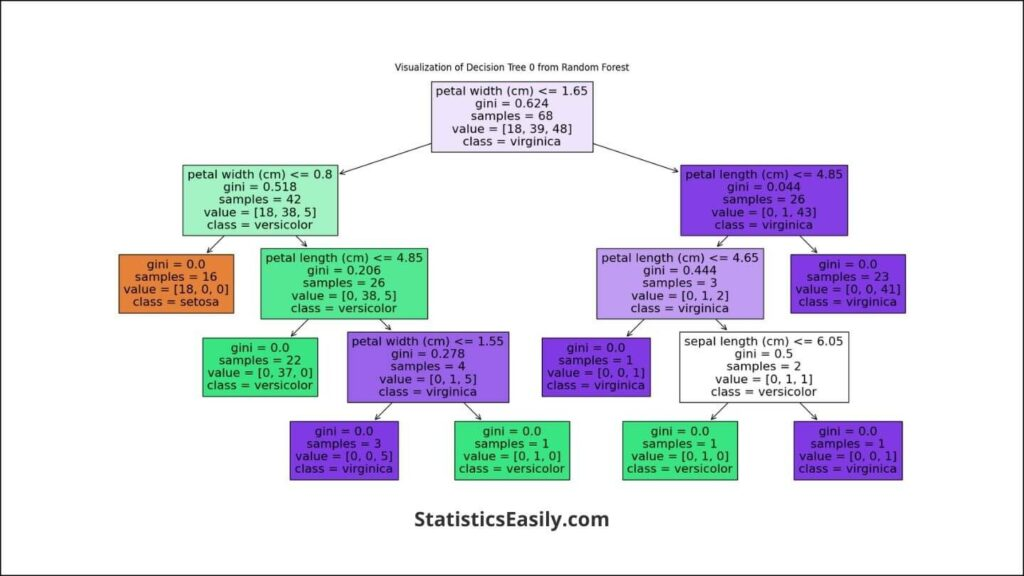

Clasificación vs Regresión

||Clasificación (Iris)|Regresión (ej. precio de casa)|
|-|-|-|
|Hoja predice|una clase (class = virginica)|un número (value = 234.500)|
|Métrica de impureza|Gini|MSE o varianza|
|Votación final|mayoría de votos|promedio de valores|
|value en nodos|[18, 39, 48] (conteo por clase)|187.3 (media del grupo)

---
### 2.2 XGBoost

```
Random Forest:
Árbol 1 ══╗
Árbol 2 ══╬══► votación ══► predicción
Árbol 3 ══╝

XGBoost:
Árbol 1 ──► errores ──► Árbol 2 ──► errores ──► Árbol 3 ──► suma ──► predicción
```

| Hiperparámetro | Rango recomendado | Escala | ¿Por qué esa escala? |
|---|---|---|---|
| `n_estimators` | 100 – 2000 | Lineal | Usar con early stopping para encontrar el valor óptimo automáticamente| 
| `learning_rate` | 0.0001-1.0| Logarítmica | La diferencia entre 0.001 y 0.01 importa tanto como entre 0.1 y 1.0. |
| `max_depth` | 3 – 12 | Lineal | Valores bajos (3-6) son más frecuentes que en Random Forest.|
| `subsample` | 0.5 – 1.0 | Lineal | Fracción de muestras por árbol. Regularización por bagging.|
| `colsample_bytree` | 0.5 – 1.0 | Lineal | Fracción de features por árbol. Regularización por columnas.|

> 💡 `learning_rate` y `n_estimators` están inversamente relacionados. Un lr bajo requiere más árboles. Usa `early_stopping_rounds` para optimizarlos juntos automáticamente.

- **`n_estimators`** — cuántos árboles en la secuencia  
Igual que en Random Forest, pero aquí el orden importa. El árbol 50 sabe lo que hicieron los 49 anteriores.

- **'`learning_rate`'** — cuánto corrige cada árbol  
Este es el hiperparámetro más importante y no existe en Random Forest. Cuando un árbol nuevo corrige los errores del anterior, no los corrige del todo, sino solo una fracción controlada por learning_rate.


In [ ]:
learning_rate = 1.0  # cada árbol corrige el error completo
                     #  (agresivo, sobreajusta rápido)

learning_rate = 0.1  # cada árbol corrige solo el 10% del error
                     #  (prudente, necesita más árboles)

learning_rate = 0.01 # correcciones muy pequeñas
                     #  (muy prudente, necesita muchos más árboles)

Un `learning_rate` bajo necesita **más árboles** para llegar al mismo punto. La combinación típica es lr bajo + muchos árboles, porque generaliza mejor.


- **`max_depth`** — profundidad de cada árbol  
Igual que en Random Forest, pero en XGBoost los árboles suelen ser más pequeños (3-6 niveles). No necesitan ser profundos porque trabajan en equipo: lo que no captura el árbol 1 lo captura el árbol 2.

- **`subsample`** — fracción de muestras por árbol  
`subsample=0.8` significa que cada árbol ve el 80% de los datos elegidos al azar. Introduce variedad entre árboles y reduce overfitting.

- **`colsample_bytree`** — fracción de features por árbol  
El equivalente a `max_features` de Random Forest. `colsample_bytree=0.8` significa que cada árbol solo ve el 80% de las features. Igual que antes, diversifica los árboles.

- **`scale_pos_weight`** — balanceo de clases  
Este hiperparámetro no existe en Random Forest y es específico de XGBoost para problemas de clasificación con clases desbalanceadas. Por ejemplo, detección de fraude donde el 99% de transacciones son legítimas y solo el 1% son fraude.
Sin ajuste, XGBoost aprende que predecir siempre "no fraude" da un 99% de accuracy, ignorando completamente la clase minoritaria.
``` python
# Fórmula recomendada:
scale_pos_weight = nº muestras clase negativa / nº muestras clase positiva

# Ejemplo con fraude:
# 9900 transacciones normales, 100 fraudes
scale_pos_weight = 9900 / 100 = 99
```

---
### 2.3 LightGBM

```
XGBoost / Random Forest (level-wise):

Nivel 0:          [raíz]
                  /     \
Nivel 1:       [A]       [B]        ← divide A y B antes de seguir
               / \       / \
Nivel 2:     [C] [D]  [E] [F]      ← divide todos a la vez

LightGBM (leaf-wise):

Paso 1:           [raíz]
                  /     \
               [A]       [B]        ← B reduce más el error

Paso 2:           [raíz]
                  /     \
               [A]       [B]
                         / \
                       [C] [D]      ← C reduce más el error

Paso 3:           [raíz]
                  /     \
               [A]       [B]
                         / \
                       [C] [D]
                       /\
                     [E][F]
```

El árbol crece de forma asimétrica. Sigue la rama donde hay más que aprender y deja las otras sin explorar.


| Hiperparámetro | Rango recomendado | Escala | ¿Para qué sirve? |
|---|---|---|---|
| `n_estimators` | 100 – 2000 | Lineal | Igual que XGBoost, usar con early stopping. |
| `learning_rate` | 0.0001 - 1.0 | Logarítmica | Igual que XGBoost |
| `num_leaves` | 20 – 300 | Lineal | Parámetro más importante en LightGBM (no max_depth). Controla la complejidad del árbol |
| `min_child_samples` | 5 – 100 | Lineal | Mínimo de muestras en una hoja. Regularización clave contra overfitting. |
| `subsample` | 0.5 – 1.0 | Lineal | Requiere subsample_freq > 0 para activarse. |

> 💡 En LightGBM, `num_leaves` es el equivalente a `max_depth` de otros modelos. Un valor alto + pocos datos = **overfitting garantizado**.

- **`num_leaves`** — complejidad del árbol, el más importante  
El equivalente a `max_depth` en otros modelos, pero contando hojas en lugar de niveles. Más hojas = árbol más complejo = más riesgo de overfitting.

```
num_leaves=4 puede dar árboles muy distintos:

Árbol simétrico        Árbol asimétrico
(como XGBoost)         (como LightGBM)

      [raíz]                [raíz]
      /    \                /    \
    [A]    [B]            [A]    [B]
    / \    / \                   / \
  [1][2] [3][4]               [C]  [4]
  4 hojas                     / \
                             [1] [2][3]
                             4 hojas
``` 

In [ ]:
num_leaves = 31   # default, conservador
num_leaves = 100  # más complejo
num_leaves = 300  # muy complejo, peligroso con pocos datos

- **`min_child_samples`** — freno contra overfitting  
El equivalente a `min_samples_leaf` de Random Forest. Mínimo de muestras que debe tener una hoja para existir. Es especialmente importante en LightGBM porque el crecimiento leaf-wise tiende a crear hojas muy pequeñas si no se controla.

In [ ]:
min_child_samples = 20   # default
min_child_samples = 5    # hojas más pequeñas, más overfitting
min_child_samples = 100  # hojas grandes, más regularización

### Qué hace early stopping
Le dices al modelo: "entrena hasta 1000 árboles, pero si llevas X árboles seguidos sin mejorar en el conjunto de validación, para".

```python
# XGBoost
xgb = XGBClassifier(
    n_estimators=1000,        # máximo posible
    learning_rate=0.01,
    early_stopping_rounds=50  # para si 50 árboles seguidos no mejoran
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  # necesita datos de validación
    verbose=False
)

print(xgb.best_iteration)  # el árbol óptimo, ej: 347


# LightGBM
lgbm = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

print(lgbm.best_iteration_)

```

```
n_estimators:   1    50   100   200   347   400   500  ...  1000
               
Error train:    ↓    ↓    ↓     ↓     ↓     ↓     ↓         ↓
Error val:      ↓    ↓    ↓     ↓     ↓→    →↑    ↑          ↑
                                      ▲
                                 mejor punto
                                 early stopping
                                 para aquí
```



---
### 2.4 Regresión Logística

En lugar de construir árboles que hagan preguntas, la Regresión Logística busca una línea divisoria (o hiperplano en más dimensiones) que separe las clases. Con Iris separando Setosa del resto:

```
anchura pétalo
     │
 2.5 │      ·  · Virginica
     │    ·  ·
 1.5 │·········────────── línea divisoria
     │  · ·
 0.5 │· Setosa
     │
     └──────────────────── longitud pétalo
```
El modelo aprende los coeficientes de esa línea durante el entrenamiento. Esos coeficientes son los parámetros del modelo (no hiperparámetros), equivalentes a los umbrales de los nodos en los árboles.

En los árboles el overfitting viene de crecer demasiado. En Regresión Logística viene de aprender coeficientes demasiado grandes. Un coeficiente muy grande significa que el modelo es extremadamente sensible a esa feature, ajustándose al ruido de los datos de entrenamiento.
La solución es la regularización: penalizar los coeficientes grandes durante el entrenamiento.


| Hiperparámetro | Rango recomendado | Escala | ¿Para qué sirve? |
|---|---|---|---|
| `C` | 1e-4 – 100 | Logarítmica | Inverso de la regularización. C alto = menos regularización = más overfitting |
| `penalty` | 'l1', 'l2', 'elasticnet' | Categórico | L1 hace feature selection. L2 es el default. Elasticnet combina ambas. |
| `solver` | 'lbfgs', 'saga', 'liblinear' | Categórico | Depende del penalty: L1 requiere saga o liblinear. Elasticnet solo funciona con saga. |
| `max_iter` | 100 – 2000 | Lineal | No es un hiperparámetro real. Subir si aparece ConvergenceWarning |

> 💡 El único que realmente importa es `C`. Úsalo siempre en escala logarítmica: `[1e-4, 1e-3, 0.01, 0.1, 1, 10, 100]`.

> ⚠️ `max_iter` NO es un hiperparámetro de modelo. Solo controla cuántas iteraciones permite el optimizador. Si aparece `ConvergenceWarning`, sube este valor; no afecta la calidad del modelo.

- **`C`** — fuerza de regularización ⭐ el más importante  
Controla cuánto se penalizan los coeficientes grandes. Es el inverso de la regularización, lo cual es contraintuitivo:

C muy alto (ej. 100)  → poca regularización → coeficientes libres → overfitting  
C = 1 (default)       → regularización moderada → equilibrio  
C muy bajo (ej. 0.01) → mucha regularización → coeficientes pequeños → underfitting

C es como la libertad que le das al modelo para ajustarse a los datos. Con C=100 puede hacer lo que quiera, con C=0.001 está muy restringido.

Siempre se busca en escala logarítmica porque el efecto de pasar de 0.001 a 0.01 es igual de relevante que de 1 a 10.

- **`penalty`** — tipo de regularización  
Define cómo se penalizan los coeficientes. Hay tres opciones con comportamientos distintos:

    - L2 (default): penaliza el cuadrado de cada coeficiente. Los reduce a todos pero ninguno llega a cero. Todos las features siguen contribuyendo, solo con menos peso.

        coeficientes sin regularización: [4.2, 0.8, 3.1, 0.3]  
        coeficientes con L2:             [1.8, 0.4, 1.3, 0.2]  ← reducidos pero presentes
    
    - L1: penaliza el valor absoluto de cada coeficiente. Empuja algunos coeficientes exactamente a cero, 
    eliminando esas features del modelo. Hace selección automática de features.

        coeficientes sin regularización: [4.2, 0.8, 3.1, 0.3]  
        coeficientes con L1:             [2.1, 0.0, 1.4, 0.0]  ← algunas features eliminadas

    - Elasticnet: combina L1 y L2. Elimina algunas features (como L1) y reduce el resto (como L2). Se controla con l1_ratio.

Regla práctica: empieza con L2. Usa L1 si sospechas que muchas features son irrelevantes y quieres que el modelo las descarte solo.

- **`solver`** — algoritmo de optimización  
No es un hiperparámetro de modelo real, es más una restricción técnica. Cada solver es compatible con ciertos tipos de penalty:

lbfgs     → solo L2. El más rápido en datasets pequeños-medianos  
saga      → L1, L2 y elasticnet. Necesario si usas L1  
liblinear → L1 y L2. Bueno con datasets muy pequeños  

En la práctica no se optimiza solver, se elige el que es compatible con el penalty que quieres usar.

- **`max_iter`** — no es un hiperparámetro real  
Como vimos antes, solo controla cuántas iteraciones permite el optimizador para encontrar los coeficientes. Si aparece ConvergenceWarning se sube, pero no afecta la calidad del modelo.

---
## 3. ¿Qué elegir dadas las características de mi dataset?

### Por tamaño del dataset

#### Dataset pequeño (< 1.000 muestras)
```
Random Forest    → n_estimators bajo [50, 100, 150], max_depth bajo (3, 5, 8)
                   min_samples_leaf alto (5, 10) para no memorizar
                   
XGBoost/LightGBM → n_estimators bajo [100, 150, 200]
                   learning_rate bajo (0.01-0.05)
                   max_depth muy bajo (3-4)
                   subsample bajo (0.5, 0.6) para más variedad
                   
Reg. Logística   → C bajo (0.01-0.1), mucha regularización
                   penalty L2 o L1 si hay muchas features
```

El riesgo principal es overfitting. Todos los hiperparámetros van hacia más restricción.

#### Dataset grande (> 100.000 muestras)
```
Random Forest    → n_estimators alto (300, 400, 500)
                   max_depth puede ser mayor (10, 15, 20)
                   min_samples_leaf puede bajar (5, 10, 15)
                   
XGBoost/LightGBM → 
                   n_estimators medio [200, 300, 400]
                   learning_rate bajo (0.1, 0.01)
                   LightGBM es mejor opción aquí por velocidad
                   num_leaves puede subir (50-100)
                   early stopping imprescindible -> cuando el número de árboles es muy alto (500)
                   
Reg. Logística   → C puede subir (1-10), menos regularización necesaria
                   penalty = l2 o elasticnet
                   solver='saga' para datasets grandes
```

Con muchos datos el modelo tiene suficiente información para aprender patrones reales sin memorizar ruido. Se puede relajar la regularización.

### Por presencia de outliers

#### Muchos outliers
```
Random Forest    → robusto por naturaleza, los outliers quedan
                   en hojas específicas y no contaminan el resto
                   min_samples_leaf alto (5, 10) para que un outlier
                   solo no forme una hoja propia
                   
XGBoost/LightGBM → más sensible a outliers que Random Forest
                   subsample bajo (0.5, 0.6, 0.7) para que no siempre
                   aparezcan en el mismo árbol
                   learning_rate bajo para no sobreajustar a ellos
                   n_estimators alto o medio [300, 400, 500]
                   
Reg. Logística   → muy sensible a outliers
                   C bajo (mucha regularización) para limitar
                   el impacto de valores extremos
                   Mejor escalar los datos antes (StandardScaler)
```
Regla general: con muchos outliers, Random Forest es la opción más segura de las cuatro. La Regresión Logística es la más vulnerable.

### Por número de features

#### Pocas features (< 10)
```
Random Forest    → max_features='sqrt' puede ser demasiado restrictivo
                   probar max_features=None o 'log2'
                   
XGBoost/LightGBM → colsample_bytree puede subir (0.7, 0.8, 1.0)
                   no hay mucho que filtrar
                   
Reg. Logística   → penalty L2 suficiente
                   C moderado (0.1-10)
```

#### Muchas features (> 100)
```
Random Forest    → max_features='sqrt' es imprescindible
                   si no, todos los árboles usan las mismas features
                   
XGBoost/LightGBM → colsample_bytree bajo (0.3-0.5)
                   reg_alpha (L1) para eliminar features irrelevantes
                   
Reg. Logística   → penalty L1 para selección automática de features
                   C bajo para regularización fuerte
```

### Por clases desbalanceadas

#### Desbalanceo moderado (70/30, 80/20)
```
Random Forest    → class_weight='balanced'
                   el modelo pondera más los errores en la clase minoritaria
                   
XGBoost          → scale_pos_weight = nº negativos / nº positivos
                   
LightGBM         → is_unbalance=True  o
                   class_weight='balanced'
                   
Reg. Logística   → class_weight='balanced'
```

#### Desbalanceo severo (99/1, fraude, enfermedades raras)
```
Todos los modelos → mismos parámetros que arriba pero además:
                    cambiar la métrica de evaluación
                    accuracy no sirve, usar F1, AUC-ROC, precision-recall
                    
XGBoost          → scale_pos_weight = 99 (en el ejemplo 99/1)
                   eval_metric='aucpr'  (área bajo curva precision-recall)
```

Con desbalanceo severo el hiperparámetro de balanceo es obligatorio, no opcional. Sin él el modelo ignora la clase minoritaria.

### Por riesgo de overfitting o underfitting

#### El modelo sobreajusta (buen train, mal test)
```
Random Forest    → bajar max_depth
                   subir min_samples_split y min_samples_leaf
                   bajar n_estimators si es muy alto
                   
XGBoost/LightGBM → bajar learning_rate
                   bajar max_depth / num_leaves
                   subir subsample y colsample_bytree hacia 0.5-0.7
                   subir reg_alpha y reg_lambda
                   
Reg. Logística   → bajar C
                   cambiar penalty a L1 si hay features irrelevantes
```

#### El modelo no aprende (mal train y mal test)
```
Random Forest    → subir max_depth o ponerlo a None
                   bajar min_samples_split y min_samples_leaf
                   subir n_estimators
                   
XGBoost/LightGBM → subir learning_rate
                   subir max_depth / num_leaves
                   subir subsample y colsample_bytree hacia 0.9-1.0
                   bajar reg_alpha y reg_lambda
                   
Reg. Logística   → subir C
                   comprobar que los datos están escalados
```

---
## 4. Cómo explorar el espacio de hiperparámetros

---
### 4.1 Grid Search — `GridSearchCV`

Prueba **todas las combinaciones posibles** del espacio de búsqueda que definimos. Es exhaustiva pero ciega: no aprende nada de los resultados anteriores.

**El problema del escalado exponencial:**
- 3 valores de `n_estimators` × 4 valores de `max_depth` = **12 combinaciones**
- 4 × 5 × 3 = **60 combinaciones**
- 5 × 5 × 5 × 5 = **625 combinaciones** con solo 4 hiperparámetros

> **Regla:** Grid Search solo es viable con ≤ 2–3 hiperparámetros y espacio pequeño.

In [ ]:
# Grid Search sobre Random Forest

param_grid_rf = {
    'n_estimators': [100, 200, 300],         # 3 valores
    'max_depth': [None, 5, 10, 20],          # 4 valores
    'min_samples_split': [2, 5, 10]          # 3 valores
}  # Total: 3 × 4 × 3 = 36 combinaciones × 5 folds = 180 entrenamientos

print("Número de combinaciones:", 3*4*3)
print("Entrenamientos totales (con cv=5):", 3*4*3*5)
print("\nEjecutando Grid Search...")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, max_features = 'sqrt'),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\n=== RESULTADOS GRID SEARCH ===")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor accuracy (CV): {grid_search.best_score_:.4f}")
print(f"Accuracy en test:    {grid_search.score(X_test, y_test):.4f}")

Número de combinaciones: 36
Entrenamientos totales (con cv=5): 180

Ejecutando Grid Search...

=== RESULTADOS GRID SEARCH ===
Mejores parámetros: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Mejor accuracy (CV): 0.9583
Accuracy en test:    0.9667


---
### 4.2 Random Search — `RandomizedSearchCV`

La idea clave aquí es el paper de Bergstra & Bengio (2012): en la mayoría de los problemas, **unos pocos hiperparámetros importan mucho y el resto poco**. Random Search explota esto mejor que Grid Search con el mismo presupuesto.

**Diferencia principal con Grid Search:**
- Grid Search: prueba una cuadrícula fija de puntos.
- Random Search: muestrea aleatoriamente del espacio de distribuciones.
- **Con el mismo número de trials, Random Search cubre más territorio.**

**Importante:** Random Search no tiene memoria. El trial 50 no sabe nada de los 49 anteriores.

> 💡 **Cuándo usar cada uno:**
> - Grid Search → ≤2 hiperparámetros, espacio pequeño y bien definido
> - Random Search → exploración inicial, espacios grandes, más de 3 hiperparámetros

In [4]:
# Random Search sobre Random Forest

param_distributions_rf = {
    'n_estimators': randint(100, 1000),           # Distribución entera uniforme
    'max_depth': [None, 5, 10, 20, 30],           # Lista categórica
    'min_samples_split': randint(2, 20),          # Distribución entera uniforme
    'max_features': ['sqrt', 'log2', None],       # Lista categórica
    'min_samples_leaf': randint(1, 10)            # Distribución entera uniforme
}
# Total: espacio casi infinito → muestreamos n_iter puntos

print("Random Search con 40 trials (mismos que 36 del Grid, más eficiente)")
print("Pero exploramos 5 hiperparámetros en lugar de 3.\n")

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions_rf,
    n_iter=40,            # número de combinaciones a probar
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,      # para reproducibilidad
    verbose=0
)

random_search.fit(X_train, y_train)

print("=== RESULTADOS RANDOM SEARCH ===")
print(f"Mejores parámetros: {random_search.best_params_}")
print(f"Mejor accuracy (CV): {random_search.best_score_:.4f}")
print(f"Accuracy en test:    {random_search.score(X_test, y_test):.4f}")

Random Search con 40 trials (mismos que 36 del Grid, más eficiente)
Pero exploramos 5 hiperparámetros en lugar de 3.

=== RESULTADOS RANDOM SEARCH ===
Mejores parámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 939}
Mejor accuracy (CV): 0.9667
Accuracy en test:    0.9333


---
## 5. Resumen final

| Situación | Estrategia recomendada | Por qué |
|---|---|---|
| ≤ 2 hiperparámetros, espacio pequeño | **Grid Search** | Cobertura exhaustiva garantizada, coste manejable |
| Primera exploración, muchos HPs | **Random Search** | Mejor cobertura del espacio con el mismo presupuesto |
| Tienes un resultado de Random y quieres afinar | **Coarse-to-Fine** | Refinamiento en la zona prometedora |
| Modelos grandes (XGBoost, LightGBM, NN) | **Random Search + early stopping** | El coste por trial es alto; Random Search reduce trials |
| Producción, muchos trials disponibles | Bayesian (Optuna) | Aprende de cada trial para decidir el siguiente |